In [4]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import os
import librosa
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
#INSTALLATION OF PACKAGES
!pip install tqdm

Defaulting to user installation because normal site-packages is not writeable


In [2]:
try:
    yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
except Exception as e:
    print("Error loading YAMNet:", e)
    yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

2025-05-02 15:15:32.495072: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:
# FUNCTIONS USED FOR FEATURE ECTRACTION , BUILDING AND TRAINING MODEL , EVAUATION AND TESTING


yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

# 1. FEATURE EXTRACTON

def extract_features(audio, sample_rate=16000, segment_length=0.975):
    max_len = int(segment_length * sample_rate)  # Samples per segment
    
    # Split audio into segments
    segments = []
    for i in range(0, len(audio), max_len):
        segment = audio[i:i+max_len]
        if len(segment) < max_len:
            segment = np.pad(segment, (0, max_len - len(segment)))
        segments.append(segment)
    
    # Process all segments
    all_embeddings = []
    for segment in segments:
        _, embeddings, _ = yamnet_model(segment)
        all_embeddings.append(embeddings)
    
    # Average embeddings across segments
    return tf.reduce_mean(tf.concat(all_embeddings, axis=0), axis=0)



In [11]:
# 2 PREPARE DATASET
def prepare_dataset(data_dir, test_size=0.2, random_state=42):
    features = []
    labels = []
    class_names = ['healthy','ncd', 'noise' ]  
    
    print("Processing audio files...")
    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        audio_files = [f for f in os.listdir(class_dir) if f.endswith('.wav')]
        
        for audio_file in audio_files:
            try:
                audio, sr = librosa.load(os.path.join(class_dir, audio_file), sr=16000)
                audio = audio / np.max(np.abs(audio))
                features.append(extract_features(audio))
                labels.append(class_name)
            except Exception as e:
                print(f"Error processing {audio_file}: {str(e)}")
    

    
    # Convert to numpy arrays
    X = np.array([f.numpy() for f in features])  # Convert TF tensors to numpy
    y = np.array(labels)
    
    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    y_categorical = to_categorical(y_encoded)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_categorical, test_size=test_size, random_state=random_state, stratify=y_encoded
    )
    
    return X_train, X_test, y_train, y_test, le.classes_

In [6]:
#3  BUILDING AND TRAINING

def build_model(input_shape, num_classes):
   
    model = Sequential([
        Dense(512, activation='relu', input_shape=input_shape),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def train_model(data_dir, epochs=50, batch_size=32):
    # Prepare dataset
    X_train, X_test, y_train, y_test, class_names = prepare_dataset(data_dir)
    
    # Build model
    model = build_model((1024,), len(class_names))
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True)
        ]
    )
    
    return model, history, class_names

In [25]:
#EVALUATION 
def evaluate_model(model, X_test, y_test, class_names):
    # Evaluate on test set
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f"\nTest Accuracy: {accuracy:.2%}")
    
   
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)
    
    
    print("\nClassification Report:")
    print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))
    
   
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

def predict_audio_file(model, file_path, class_names):
    """Predict class for a single audio file"""
    audio, sr = librosa.load(file_path, sr=16000)
    audio = audio / np.max(np.abs(audio))  
    
    features = extract_features(audio)
    features = np.expand_dims(features, axis=0)  
    
    probs = model.predict(features)[0]
    pred_class = class_names[np.argmax(probs)]
    
    print("\nPrediction Results:")
    for i, class_name in enumerate(class_names):
        print(f"{class_name}: {probs[i]:.2%}")
    
    print(f"\nPredicted class: {pred_class}")
    return pred_class, probs

In [17]:
# THE ACTUAL CODE
DATA_DIR = "/home/takudzwa/Documents/Projects/broiler_disease/detection/models/Chicken_Audio_Dataset"
#TRAINING
model, history, class_names = train_model(DATA_DIR, epochs=10)


Processing audio files...
Epoch 1/10


/home/takudzwa/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5126 - loss: 1.0446

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.5818 - loss: 0.9602 - val_accuracy: 0.7857 - val_loss: 0.6010
Epoch 2/10
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8623 - loss: 0.5182

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8538 - loss: 0.4964 - val_accuracy: 0.8429 - val_loss: 0.4687
Epoch 3/10
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8581 - loss: 0.3962

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8662 - loss: 0.3745 - val_accuracy: 0.8857 - val_loss: 0.3928
Epoch 4/10
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9147 - loss: 0.2872

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9050 - loss: 0.2897 - val_accuracy: 0.9000 - val_loss: 0.3368
Epoch 5/10
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9433 - loss: 0.2012

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9393 - loss: 0.2058 - val_accuracy: 0.9143 - val_loss: 0.3344
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9298 - loss: 0.2345

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9317 - loss: 0.2302 - val_accuracy: 0.9286 - val_loss: 0.3283
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9726 - loss: 0.1241 - val_accuracy: 0.8857 - val_loss: 0.3551
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9395 - loss: 0.1651 - val_accuracy: 0.9143 - val_loss: 0.3535
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9602 - loss: 0.1166 - val_accuracy: 0.8571 - val_loss: 0.5118
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9537 - loss: 0.1318 - val_accuracy: 0.9143 - val_loss: 0.3889


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9213 - loss: 0.3417

Test Accuracy: 92.86%
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Classification Report:
              precision    recall  f1-score   support

     healthy       0.88      1.00      0.93        28
         ncd       1.00      0.96      0.98        25
       noise       0.93      0.76      0.84        17

    accuracy                           0.93        70
   macro avg       0.93      0.91      0.92        70
weighted avg       0.93      0.93      0.93        70



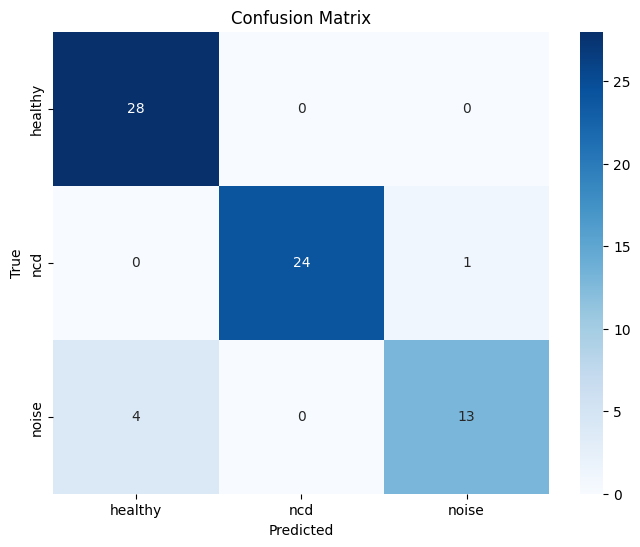

In [28]:
 # _, X_test, _, y_test, _ = prepare_dataset(DATA_DIR)
evaluate_model(model, X_test, y_test, class_names)
 

In [32]:
#Testing  
test_file = "/home/takudzwa/Documents/Projects/broiler_disease/detection/models/test_audio/testing.wav"
predict_audio_file(model, test_file, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Prediction Results:
healthy: 21.26%
ncd: 0.28%
noise: 78.46%

Predicted class: noise


(np.str_('noise'), array([0.21255001, 0.00284007, 0.7846099 ], dtype=float32))

In [23]:

# 1. MODEL FOR ESP32
esp32_converter = tf.lite.TFLiteConverter.from_keras_model(model)
esp32_converter.optimizations = [tf.lite.Optimize.DEFAULT]


esp32_tflite = esp32_converter.convert()

esp32_path = '/home/takudzwa/Documents/PlatformIO/Projects/Broiler Disease Detection/broiler_disease_audio_esp32.tflite'
with open(esp32_path, 'wb') as f:
    f.write(esp32_tflite_model)
print(f"ESP32 model saved to: {esp32_path}")
print(f"ESP32 model size: {len(esp32_tflite_model)/1024:.2f} KB")

# 2. MODEL DJANGO 
django_converter = tf.lite.TFLiteConverter.from_keras_model(model)
django_converter.optimizations = [tf.lite.Optimize.DEFAULT]  
django_tflite_model = django_converter.convert()

django_path = '/home/takudzwa/Documents/Projects/broiler_disease/final_year_broiler/broiler_disease_audio.tflite'
with open(django_path, 'wb') as f:
    f.write(django_tflite_model)
print(f"Django model saved to: {django_path}")
print(f"Django model size: {len(django_tflite_model)/1024:.2f} KB")

# keras_path = 'models/django/broiler_disease.h5'
# model.save(keras_path)
# print(f"Keras model saved to: {keras_path}")


INFO:tensorflow:Assets written to: /tmp/tmp8q2ab0lm/assets


INFO:tensorflow:Assets written to: /tmp/tmp8q2ab0lm/assets


Saved artifact at '/tmp/tmp8q2ab0lm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  127484317080160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127484317085792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127484317075936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127484317087904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127484317074528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127484317079104: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1746305719.459228   35245 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1746305719.459252   35245 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-03 22:55:19.459468: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp8q2ab0lm
2025-05-03 22:55:19.459999: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-03 22:55:19.460016: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp8q2ab0lm
2025-05-03 22:55:19.464644: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-03 22:55:19.494803: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp8q2ab0lm
2025-05-03 22:55:19.504010: I tensorflow/cc/saved_model/loader.cc:466] SavedModel load for tags { serve }; Status: success: OK. Took 44544 microseconds.


ESP32 model saved to: /home/takudzwa/Documents/PlatformIO/Projects/Broiler Disease Detection/models/broiler_disease_audio_esp32.tflite
ESP32 model size: 1285.82 KB
INFO:tensorflow:Assets written to: /tmp/tmprrb57vl9/assets


INFO:tensorflow:Assets written to: /tmp/tmprrb57vl9/assets


Saved artifact at '/tmp/tmprrb57vl9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  127484317080160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127484317085792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127484317075936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127484317087904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127484317074528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127484317079104: TensorSpec(shape=(), dtype=tf.resource, name=None)
Django model saved to: /home/takudzwa/Documents/Projects/broiler_disease/final_year_broiler/broiler_disease_audio.tflite
Django model size: 657.14 KB


W0000 00:00:1746305720.801974   35245 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1746305720.801994   35245 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-03 22:55:20.802218: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmprrb57vl9
2025-05-03 22:55:20.802984: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-03 22:55:20.803002: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmprrb57vl9
2025-05-03 22:55:20.809261: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-03 22:55:20.845414: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmprrb57vl9
2025-05-03 22:55:20.856494: I tensorflow/cc/saved_model/loader.cc:466] SavedModel load for tags { serve }; Status: success: OK. Took 54280 microseconds.
